# Выбор локации для скважины

Допустим, вы работаете в добывающей компании «ГлавРосГосНефть». Нужно решить, где бурить новую скважину.

Вам предоставлены пробы нефти в трёх регионах: в каждом 100 000 месторождений, где измерили качество нефти и объём её запасов. Постройте модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой *Bootstrap.*

Шаги для выбора локации:

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.

## Загрузка и подготовка данных

In [1]:
pip install phik

     |████████████████████████████████| 677 kB 2.0 MB/s eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
#необходимые импорты
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.utils import resample
import os
from phik import phik_matrix

In [3]:
def load_all_data() -> None:
    """
    Загружает 3 CSV-файла проекта и создаёт переменные с информативными названиями:
    - geo_data_0: данные геологоразведки региона 1
    - geo_data_1: данные геологоразведки региона 2
    - geo_data_2: данные геологоразведки региона 3

    """

    # Пути к папкам
    local_path = "./data"
    server_path = "/datasets"

    # Словарь: имя переменной -> (имя файла, описание)
    files = {
        'geo_data_0': ('geo_data_0.csv', 'данные геологоразведки региона 1'),
        'geo_data_1': ('geo_data_1.csv', 'данные геологоразведки региона 2'),
        'geo_data_2': ('geo_data_2.csv', 'данные геологоразведки региона 3'),
    }

    for var_name, (file_name, desc) in files.items():
        # Проверяем два пути
        for base_path in (local_path, server_path):
            full_path = os.path.join(base_path, file_name)
            if os.path.exists(full_path):
                break
        else:
            raise FileNotFoundError(f"Файл {file_name} не найден ни в {local_path}, ни в {server_path}")

        # Читаем CSV 
        df = pd.read_csv(full_path) #, index_col='id'сразу ставим 'id' в индекс

        # Сохраняем в глобальную область видимости
        globals()[var_name] = df

        print(f"\n# {var_name}  ←  {full_path}  ({desc})")
        print(df.info())
        display(df.head())

In [4]:
load_all_data()


# geo_data_0  ←  /datasets/geo_data_0.csv  (данные геологоразведки региона 1)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None


,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647



# geo_data_1  ←  /datasets/geo_data_1.csv  (данные геологоразведки региона 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None


,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305



# geo_data_2  ←  /datasets/geo_data_2.csv  (данные геологоразведки региона 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None


,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


<span style="color:green;"> **Вывод:**
    
<span style="color:green;"> все три датасета содержат по 100000 записей, отсутствуют пропущенные значения в столбцах, названия столбцов соответствуют названиям в описании, тип данных верный.
</span>

In [5]:
#предобработка данных
def preprocess_geo(df: pd.DataFrame, name: str = ''):
    """
    EDA для уже загруженного geo_data_*.csv
    name - подпись для заголовков (например, 'geo_data_0')
    Возвращает df без неявных дубликатов и печатает весь отчёт.
    """
    print(f'--- {name} ---')

    #пропуски
    na_counts = df.isna().sum()
    if na_counts.sum() == 0:
        print('Пропусков нет.')
    else:
        print('Пропуски:', na_counts[na_counts > 0].to_dict())

    #дубликаты
    dup_all = df.duplicated().sum()
    dup_sub = df.drop(columns='id').duplicated().sum()
    print(f'Явных дубликатов: {dup_all}, неявных (без id): {dup_sub}')

    #уникальные id
    print(f'Уникальных скважин: {df["id"].nunique()} / {len(df)}')

    #гистограмма product
    plt.figure(figsize=(6, 3))
    sns.histplot(df['product'], bins=50, kde=True)
    plt.title(f'{name} – распределение product')
    plt.show()

    #box-plot
    plt.figure(figsize=(3, 4))
    sns.boxplot(y=df['product'])
    plt.title(f'{name} – box-plot product')
    plt.show()

    #выбросы IQR (полуторный размах)
    q1, q3 = df['product'].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers = df[(df['product'] < lower) | (df['product'] > upper)]
    print(f'Выбросов по IQR: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')

    # Выбросы TQR (тройной интерквартальный размах)
    q1, q3 = df['product'].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 3*iqr, q3 + 3*iqr
    outliers = df[(df['product'] < lower) | (df['product'] > upper)]
    print(f'Выбросов по TQR: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')
    
    #чистый датасет
    df_clean = df.drop_duplicates(subset=['f0','f1','f2','product'])
    print(f'После удаления неявных дубликатов: {len(df_clean)} записей\n')
    return df_clean

--- geo_data_0 ---
Пропусков нет.
Явных дубликатов: 0, неявных (без id): 0
Уникальных скважин: 99990 / 100000


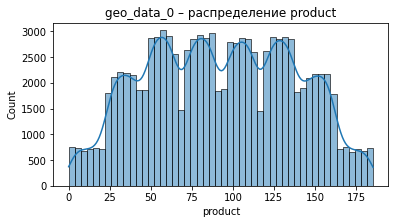

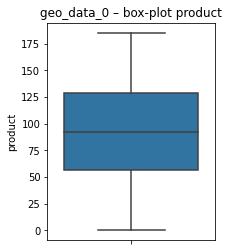

Выбросов по IQR: 0 (0.00%)
Выбросов по TQR: 0 (0.00%)
После удаления неявных дубликатов: 100000 записей



In [6]:
geo_0_clean = preprocess_geo(geo_data_0, 'geo_data_0')

--- geo_data_1 ---
Пропусков нет.
Явных дубликатов: 0, неявных (без id): 0
Уникальных скважин: 99996 / 100000


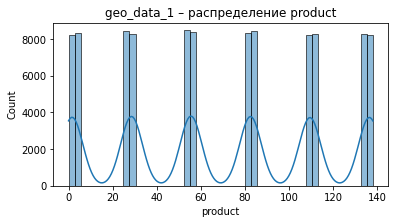

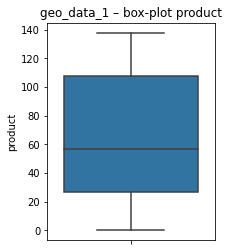

Выбросов по IQR: 0 (0.00%)
Выбросов по TQR: 0 (0.00%)
После удаления неявных дубликатов: 100000 записей



In [7]:
geo_1_clean = preprocess_geo(geo_data_1, 'geo_data_1')

--- geo_data_2 ---
Пропусков нет.
Явных дубликатов: 0, неявных (без id): 0
Уникальных скважин: 99996 / 100000


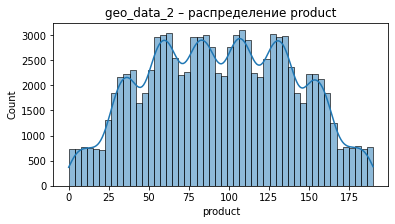

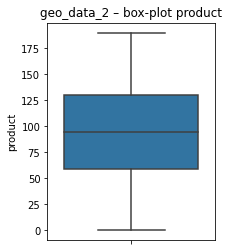

Выбросов по IQR: 0 (0.00%)
Выбросов по TQR: 0 (0.00%)
После удаления неявных дубликатов: 100000 записей



In [8]:
geo_2_clean = preprocess_geo(geo_data_2, 'geo_data_2')

В датасетах нет ни одной ячейки-пропуска (NaN) ни в одном столбце.
«Явных» дубликатов – полностью идентичные строки (включая id): 0 штук.
«Неявных»  дубликатов – строки, у которых совпадают ВСЕ признаки кроме id (f0, f1, f2, product): тоже 0 штук.
Уникальных значений в колонке id  от 99 990 до 99 996, хотя записей в каждом датасете 100 000.⇒ id повторяются. В регионе 1 большинство скважин имеют объём нефти в районе 100 тысяч баррелей. В регионе 2 скважины в целом дают меньше нефти по сравнению с первым  и третьим регионами. Во всех трех датасетах есть количество скважин, которые дают гораздо больше нефти, чем среднее. Они как раз таки будут нас интересовать с точки зрения прибыли

In [9]:
# Функция для построения ΦK-матрицы
def plot_phik_matrix(df, dataset_name):
    # Удаляем столбец id из анализа
    df = df.drop(columns=['id'])
    
    # Определяем числовые колонки
    interval_cols = df.select_dtypes(include='float64').columns
    
    # Вычисляем ΦK-матрицу
    phik_matrix = df.phik_matrix(interval_cols=interval_cols)
    
    # Визуализация
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        phik_matrix,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        vmin=0,
        vmax=1,
        cbar_kws={'label': 'ΦK correlation'}
    )
    plt.title(f'Матрица корреляций (ΦK) для {dataset_name}')
    plt.tight_layout()
    plt.show()

ΦK-матрица для региона 1:


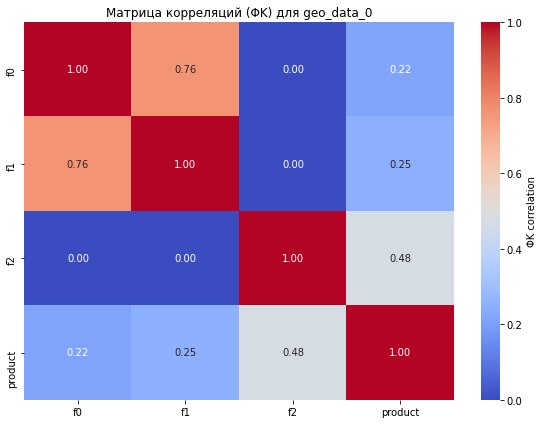


ΦK-матрица для региона 2:


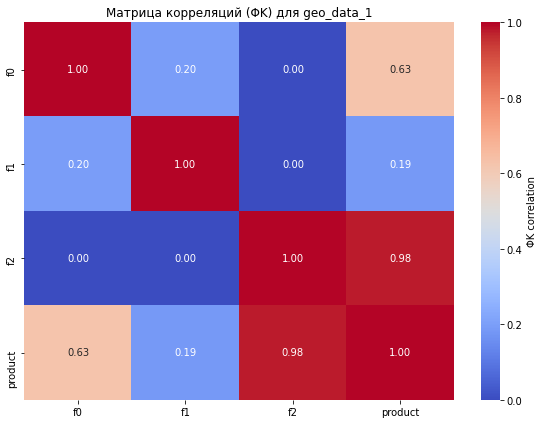


ΦK-матрица для региона 3:


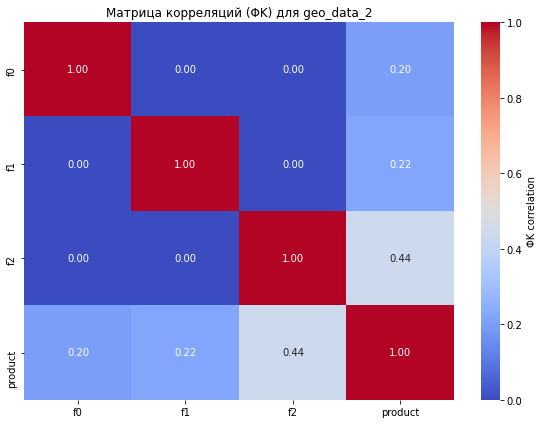

In [10]:
# Строим матрицы для каждого датасета
print("ΦK-матрица для региона 1:")
plot_phik_matrix(geo_data_0, 'geo_data_0')

print("\nΦK-матрица для региона 2:")
plot_phik_matrix(geo_data_1, 'geo_data_1')

print("\nΦK-матрица для региона 3:")
plot_phik_matrix(geo_data_2, 'geo_data_2')

Для региона 1 f0, f1 и f2 имеют слабую взаимосвязь с целевым признаком product. Или она вовсе отсутствует. Для региона 2 f0 имеет среднюю взаимосвязь с целевым признаком, f2 сильную, а f1 слабую( или отсутствие связи). Регион 3 характеризуется слабой взаимосвязью f0 и  f1 c product, а f2 средней взаимосвязью.

## Обучение и проверка модели

In [11]:
#функция для обучения и проверки модели для каждого региона
def train_and_evaluate_model(df, test_size=0.25, random_state=42):
    """
    Обучает линейную регрессию на предоставленном датафрейме и оценивает ее на валидационной выборке.
    """
    # Разбиение данных на обучающую и валидационную выборки в соотношении 75:25.
    X = df[['f0', 'f1', 'f2']]
    y = df['product']
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=test_size, random_state=random_state)
    
    # Обучение модели и сделайте предсказания на валидационной выборке.
    model = LinearRegression()
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    
    # Сохраним предсказания и правильные ответы на валидационной выборке.
    predictions = val_pred
    actuals = y_val
    
    # Напечатаем на экране средний запас предсказанного сырья и RMSE модели.
    rmse = mean_squared_error(actuals, predictions, squared=False)
    mean_volume = predictions.mean()
    print(f"Средний запас предсказанного сырья: {mean_volume:.2f} тыс. барр.")
    print(f"RMSE модели: {rmse:.2f}")
    
    return model, predictions, actuals, rmse, mean_volume

In [12]:
#обучение и проверка модели для региона 1
model_0, val_pred_0, y_val_0, rmse_0, mean_volume_0 = train_and_evaluate_model(geo_data_0)

Средний запас предсказанного сырья: 92.40 тыс. барр.
RMSE модели: 37.76


In [13]:
#обучение и проверка модели для региона 2
model_1, val_pred_1, y_val_1, rmse_1, mean_volume_1 = train_and_evaluate_model(geo_data_1)

Средний запас предсказанного сырья: 68.71 тыс. барр.
RMSE модели: 0.89


In [14]:
#обучение и проверка модели для региона 3
model_2, val_pred_2, y_val_2, rmse_2, mean_volume_2 = train_and_evaluate_model(geo_data_2)

Средний запас предсказанного сырья: 94.77 тыс. барр.
RMSE модели: 40.15


***Модель для Региона 2 показывает наилучшую точность в предсказаниях, что может сделать его привлекательным для инвестиций, если другие условия также выгодны. Регион 1 и Регион 3 показывают более высокие RMSE, что может указывать на существенную неопределенность в предсказаниях. Это может потребовать дальнейшего анализа и возможного улучшения модели. Средние запасы сырья в Регионах 1 и 3 выше, чем в Регионе 2, что может компенсировать более высокую RMSE, в зависимости от риска, который empresa готова принять. Так же принятие решений о разработке новых скважин в регионе должно также учитывать другие факторы, такие как стоимость разработки, рыночная цена сырья и другие экономические и геологические условия.(пишу как сотрудник научно-исследовательского института нефтегазовой отрасли)***

## Подготовка к расчёту прибыли

In [15]:
# Константы для расчетов
barrel_price = 450000  # стоимость одного барреля сырья
BUDGET = 10000000000  # бюджет на разработку скважин
FIXED_COST = BUDGET  # фиксированные затраты
N_TOTAL = 500  # всего исследуемых точек
N_SELECT = 200  # количество лучших точек для разработки
BOOTSTRAP_SAMPLES = 1000  # количество выборок для Bootstrap
def prepare_and_calculate_profit(df, model, barrel_price, fixed_cost, n_select):
    """
    Подготовка и расчет прибыли для региона на основе предсказанных объёмов сырья.
    """
    #Рассчитаем достаточный объём сырья для безубыточной разработки новой скважины
    break_even_volume = fixed_cost / (n_select * barrel_price)
    
    #Добавление предсказаний объёмов сырья в DataFrame
    df['predicted_volume'] = model.predict(df[['f0', 'f1', 'f2']])
    
    #Выборка лучших скважин. убрала расчет потенциальной прибыли
    top_n = df.nlargest(n_select, 'predicted_volume')
    total_predicted_volume = top_n['predicted_volume'].sum()
    revenue = total_predicted_volume * barrel_price
    #profit = revenue - fixed_cost
    
    #Сравнение среднего запаса сырья с безубыточным объёмом
    mean_predicted_volume = df['predicted_volume'].mean()
    is_profitable = mean_predicted_volume >= break_even_volume
    
    return {
        'top_n': top_n,
        'total_predicted_volume': total_predicted_volume,
        'revenue': revenue,
        #'profit': profit,
        'mean_predicted_volume': mean_predicted_volume,
        'is_profitable': is_profitable,
        'break_even_volume': break_even_volume
    }


In [16]:
# Применение функции подготовки к расчету прибыли к данным каждого региона
for i, (geo_data, model) in enumerate(zip([geo_data_0, geo_data_1, geo_data_2], [model_0, model_1, model_2]), 1):
    print(f"Результаты для региона {i}:")
    profit_calc = prepare_and_calculate_profit(geo_data, model, barrel_price, FIXED_COST, N_SELECT)
    
   # print(f"Потенциальная прибыль: {profit_calc['profit']:.2f} руб.")
    print(f"Средний запас сырья: {profit_calc['mean_predicted_volume']:.2f} тыс. барр.")
    print(f"Достаточность объёма сырья для безубыточной разработки: {'Да' if profit_calc['is_profitable'] else 'Нет'}")
    print(f"Достаточный объём сырья: {profit_calc['break_even_volume']:.2f} тыс. барр.")
    print(f"Средний предсказанный объём сырья: {profit_calc['mean_predicted_volume']:.2f} тыс. барр.")
    print("\n")


Результаты для региона 1:
Средний запас сырья: 92.52 тыс. барр.
Достаточность объёма сырья для безубыточной разработки: Нет
Достаточный объём сырья: 111.11 тыс. барр.
Средний предсказанный объём сырья: 92.52 тыс. барр.


Результаты для региона 2:
Средний запас сырья: 68.82 тыс. барр.
Достаточность объёма сырья для безубыточной разработки: Нет
Достаточный объём сырья: 111.11 тыс. барр.
Средний предсказанный объём сырья: 68.82 тыс. барр.


Результаты для региона 3:
Средний запас сырья: 94.91 тыс. барр.
Достаточность объёма сырья для безубыточной разработки: Нет
Достаточный объём сырья: 111.11 тыс. барр.
Средний предсказанный объём сырья: 94.91 тыс. барр.




Для всех трех регионов получили следующие результаты:

Регион 1: средний запас сырья равен 92,52 тысячи баррелей. Для безубыточной разработки недостаточен объём сырья, который составляет 111,11 тысячи баррелей.

Регион 2: средний запас сырья равен 68,82 тысячи баррелей. Также для этого региона недостаточен объём сырья для безубыточной разработки, необходимо не менее 111,11 тысячи баррелей.

Регион 3: средний запас сырья равен 94,91 тысячи баррелей. Как и в предыдущих регионах, объём сырья для безубыточной разработки недостаточен, требуется 111,11 тысячи баррелей.

Вывод: В каждом регионе средний предсказанный объём сырья ниже порога безубыточной разработки, что указывает на то, что для обеспечения прибыльности проекта необходимо увеличить объём сырья или пересмотреть бюджетные затраты.

## Расчёт прибыли и рисков 

In [17]:
def calculate_profit(target, predictions, N_SELECT, barrel_price, FIXED_COST):
    """
    Вычисляет прибыль для выбранных скважин и предсказанных объёмов сырья.
    """
    # Сортируем предсказанные значения и получаем индексы сортировки
    sorted_indices = predictions.argsort()[::-1]  # индексы отсортированных предсказаний по убыванию 
    # Отбираем таргет по индексу предикта, отбираем 200 лучших именно по таргету
    top_target = target.iloc[sorted_indices[:N_SELECT]]
    
    # Расчитываем прибыль для полученного объёма сырья 
    total_volume = top_target.sum()
    revenue = total_volume * barrel_price
    profit = revenue - FIXED_COST
    
    return total_volume, profit

def bootstrap_risk(target, predictions, BOOTSTRAP_SAMPLES, N_SELECT, barrel_price, FIXED_COST):
    """
    Применение метода Bootstrap для оценки рисков и прибыли.
    """
    profits = []
    for i in range(BOOTSTRAP_SAMPLES):
        # Отбор случайных таргет значений (с возможностью повторения)
        target_sample = target.sample(N_TOTAL, replace=True, random_state=i)
        predictions_sample = predictions[target_sample.index]
        
        # Расчет прибыли для каждой бутстрэп-выборки
        total_volume, bootstrap_profit = calculate_profit(target_sample, predictions_sample, N_SELECT, barrel_price, FIXED_COST)
        profits.append(bootstrap_profit)
    
    # Расчет среднего, доверительных интервалов и рисков
    mean_profit = np.mean(profits)
    ci_lower, ci_upper = np.percentile(profits, [2.5, 97.5])
    risk_of_loss = np.mean(np.array(profits) < 0)  # доля выборок с убытками
    
    return mean_profit, (ci_lower, ci_upper), risk_of_loss

In [18]:
results = []
for i, (geo_data, model) in enumerate(zip([geo_data_0, geo_data_1, geo_data_2], [model_0, model_1, model_2]), 1):
    # Получение предсказаний модели
    predictions = model.predict(geo_data[['f0', 'f1', 'f2']])
    target = geo_data['product']
    # Расчет прибыли
    total_volume, profit = calculate_profit(target, predictions, N_SELECT, barrel_price, FIXED_COST)
    # Расчет рисков и прибыли с использованием Bootstrap
    mean_profit, confidence_interval, risk_of_loss = bootstrap_risk(target, predictions, BOOTSTRAP_SAMPLES, N_SELECT, barrel_price, FIXED_COST)
    # Сохранение результатов
    results.append({
        'region': f'Регион {i}',
        'total_volume': total_volume,
        'profit': profit,
        'mean_profit': mean_profit,
        'confidence_interval': confidence_interval,
        'risk_of_loss': risk_of_loss
    })

# Вывод результатов
for result in results:
    print(f"{result['region']}:")
    print(f"  Объём сырья: {result['total_volume']:.2f} тыс. барр.")
    print(f"  Потенциальная прибыль: {result['profit']:.2f} руб.")
    print(f"  Средняя прибыль (Bootstrap): {result['mean_profit']:.2f} руб.")
    print(f"  95%-й доверительный интервал: [{result['confidence_interval'][0]:.2f}, {result['confidence_interval'][1]:.2f}] руб.")
    print(f"  Риск убытков: {result['risk_of_loss'] * 100:.2f}%\n")

Регион 1:
  Объём сырья: 30055.95 тыс. барр.
  Потенциальная прибыль: 3525175504.51 руб.
  Средняя прибыль (Bootstrap): 433108439.60 руб.
  95%-й доверительный интервал: [-65294264.88, 972407282.48] руб.
  Риск убытков: 3.60%

Регион 2:
  Объём сырья: 27589.08 тыс. барр.
  Потенциальная прибыль: 2415086696.68 руб.
  Средняя прибыль (Bootstrap): 436554601.47 руб.
  95%-й доверительный интервал: [41716778.22, 821589171.22] руб.
  Риск убытков: 1.80%

Регион 3:
  Объём сырья: 27991.05 тыс. барр.
  Потенциальная прибыль: 2595973993.44 руб.
  Средняя прибыль (Bootstrap): 369229085.35 руб.
  95%-й доверительный интервал: [-136000804.91, 849236198.89] руб.
  Риск убытков: 8.20%



In [19]:
#Выбор региона для разработки скважин
best_region = max(results, key=lambda x: x['mean_profit'])
print(f"Рекомендуется разрабатывать скважины в {best_region['region']}, так как он имеет наибольшую среднюю прибыль ({best_region['mean_profit']:.2f} руб.) и низкий риск убытков ({best_region['risk_of_loss']*100:.2f}%).")

Рекомендуется разрабатывать скважины в Регион 2, так как он имеет наибольшую среднюю прибыль (436554601.47 руб.) и низкий риск убытков (1.80%).
